In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from PIL import Image
from pathlib import Path

from brainvision.constants import *
from brainvision.models import (Baseline1DDNN, FabeloDNN, Fabelo2DCNN,
                                 HuEtAl1DCNN, LeeEtAl2DCNN,
                                 HamidaEtAl3DCNN, HybridSN, SpectralFormer)
from brainvision.data.io import load_processed_patients, unzip_patient
from brainvision.utils import build_run_name

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
#                        CONFIGURE PREDICTION HERE
# ══════════════════════════════════════════════════════════════════════════════

# MODEL, LOSS_FN, STRATEGY, REDUCE_PIXELS, and VISUALISE_FOLD together
# identify which checkpoint to load — they must match the training run
# exactly. They do NOT affect how inference is performed.
MODEL          = "1D-NN-Fabelo"
LOSS_FN        = "CE"
STRATEGY       = "vp_fabelo"
REDUCE_PIXELS  = True
VISUALISE_FOLD = 1

# Patients to generate prediction maps for.
# Can be from any campaign — not restricted to the test set.
VISUALISE_PATIENTS = [
    "004-02",
    "012-01",
]

# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
PATCH_MODELS = {'2D-CNN', '2D-CNN-Fabelo', '3D-CNN', 'HybridSN'}

MODEL_REGISTRY = {
    '1D-NN'         : lambda: Baseline1DDNN(N_DECIMATED_BANDS, N_CLASSES,
                                             dropout=True,
                                             dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo'  : lambda: FabeloDNN(N_DECIMATED_BANDS, N_CLASSES),
    '1D-CNN'        : lambda: HuEtAl1DCNN(N_DECIMATED_BANDS, N_CLASSES),
    '2D-CNN'        : lambda: LeeEtAl2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                             PATCH_SIZE),
    '2D-CNN-Fabelo' : lambda: Fabelo2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                         PATCH_SIZE),
    '3D-CNN'        : lambda: HamidaEtAl3DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                               PATCH_SIZE),
    'HybridSN'      : lambda: HybridSN(N_DECIMATED_BANDS, PATCH_SIZE,
                                        N_CLASSES),
    'SpectralFormer': lambda: SpectralFormer(N_DECIMATED_BANDS, N_CLASSES,
                                              near_band   = SF_NEAR_BAND,
                                              dim         = SF_DIM,
                                              depth       = SF_DEPTH,
                                              heads       = SF_HEADS,
                                              dim_head    = SF_DIM_HEAD,
                                              mlp_dim     = SF_MLP_DIM,
                                              dropout     = SF_DROPOUT,
                                              emb_dropout = SF_EMB_DROPOUT,
                                              mode        = SF_MODE),
}

In [56]:
run_name = build_run_name(
    model         = MODEL,
    loss_fn       = LOSS_FN,
    strategy      = STRATEGY,
    fold          = VISUALISE_FOLD,
    reduce_pixels = REDUCE_PIXELS,
)

checkpoint_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"

assert checkpoint_path.exists(), \
    f"Checkpoint not found: {checkpoint_path}\n" \
    f"Check MODEL, LOSS_FN, STRATEGY, REDUCE_PIXELS, VISUALISE_FOLD."

model = MODEL_REGISTRY[MODEL]().to(device)
model.load_state_dict(
    torch.load(checkpoint_path, map_location=device, weights_only=True)
)
model.eval()

print(f"Run      : {run_name}")
print(f"Params   : {sum(p.numel() for p in model.parameters()):,}")
print(f"Checkpoint: {checkpoint_path.name}  ✅")

Run      : 1dnnfabelo_ce_bal_fold1_vpfabelo
Params   : 4,936
Checkpoint: 1dnnfabelo_ce_bal_fold1_vpfabelo.pt  ✅


In [57]:
def load_patient_for_viz(patient_id: str) -> dict | None:
    """
    Find and load a preprocessed patient by ID across all campaigns.
    Also loads JPEG previews from the raw zip if available.
    """
    for campaign_id, data_dir in PROCESSED_DIRS.items():
        npz_path = Path(data_dir) / f"{patient_id}.npz"
        if not npz_path.exists():
            continue

        print(f"  Found {patient_id} in Campaign {campaign_id}")
        data       = np.load(npz_path)
        image_jpg  = None
        gt_map_jpg = None

        raw_zip = Path(CAMPAIGN_DIRS[campaign_id]) / f"{patient_id}.zip"
        if raw_zip.exists():
            result = unzip_patient(str(raw_zip))

            # Handle both old (Path) and new (dict) return types
            folder     = result['folder'] if isinstance(result, dict) else result
            image_jpg  = folder / 'image.jpg'
            gt_map_jpg = folder / 'gtMap.jpg'

        return {
            'id'        : patient_id,
            'processed' : data['processed'],   # (H, W, 128)
            'labels'    : data['labels'],       # (H, W)
            'image'     : image_jpg,
            'gt_map'    : gt_map_jpg,
        }

    print(f"  ⚠️  Patient {patient_id} not found in any campaign")
    return None

In [58]:
import time

@torch.no_grad()
def predict_full_image(patient: dict) -> tuple[np.ndarray, dict]:
    """
    Run inference on every labelled pixel in the patient image.
    Returns:
      pred_map   : (H, W) int32  — -1=unlabelled, 0–3=predicted class
      timing     : dict with inference time breakdown
    """
    cube      = patient['processed']
    label_map = patient['labels']
    H, W, C   = cube.shape
    pred_map  = np.full((H, W), -1, dtype=np.int32)

    # Count labelled pixels
    mask        = label_map > 0
    n_pixels    = mask.sum()

    t_start = time.perf_counter()

    if MODEL in PATCH_MODELS:
        half   = PATCH_SIZE // 2
        padded = np.pad(cube, ((half,half),(half,half),(0,0)),
                        mode='reflect').astype(np.float32)
        ys, xs = np.where(mask)

        if len(ys) == 0:
            print("  ⚠️  No labelled pixels found")
            return pred_map, {}

        all_preds  = []
        batch_size = 512

        for start in range(0, len(ys), batch_size):
            batch_ys = ys[start:start+batch_size]
            batch_xs = xs[start:start+batch_size]
            patches  = np.stack([
                padded[y:y+PATCH_SIZE, x:x+PATCH_SIZE, :].transpose(2,0,1)
                for y, x in zip(batch_ys, batch_xs)
            ]).astype(np.float32)
            logits = model(torch.tensor(patches).to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())

        for y, x, p in zip(ys, xs, all_preds):
            pred_map[y, x] = p

    else:
        pixels      = cube.reshape(-1, C).astype(np.float32)
        flat_labels = label_map.reshape(-1)
        flat_mask   = flat_labels > 0
        labelled_px = pixels[flat_mask]
        preds       = []
        bs          = 4096

        for start in range(0, len(labelled_px), bs):
            logits = model(torch.tensor(
                labelled_px[start:start+bs]).to(device))
            preds.extend(logits.argmax(1).cpu().numpy())

        flat_pred          = np.full(H * W, -1, dtype=np.int32)
        flat_pred[flat_mask] = preds
        pred_map           = flat_pred.reshape(H, W)

    t_end        = time.perf_counter()
    elapsed_ms   = (t_end - t_start) * 1000

    timing = {
        'total_ms'       : elapsed_ms,
        'total_s'        : elapsed_ms / 1000,
        'n_pixels'       : int(n_pixels),
        'ms_per_pixel'   : elapsed_ms / n_pixels if n_pixels > 0 else 0,
        'pixels_per_sec' : n_pixels / (elapsed_ms / 1000) if elapsed_ms > 0 else 0,
    }

    return pred_map, timing

In [59]:
TISSUE_COLORS = ['#5DCAA5', '#D85A30', '#378ADD', '#888780']
CMAP_TISSUE   = ListedColormap(['white'] + TISSUE_COLORS)
CMAP_AGREE    = ListedColormap(['#DDDDDD', '#5DCAA5', '#D85A30'])


def plot_prediction_map(patient: dict, pred_map: np.ndarray, timing: dict):
    """
    Four-panel figure:
      1. RGB preview (if available)
      2. Ground truth label map
      3. Predicted label map
      4. Agreement map (correct / incorrect / unlabelled)
    """
    label_map    = patient['labels']
    H, W         = label_map.shape
    mask         = label_map > 0

    gt_display   = label_map.astype(float) - 1   # -1=unlabelled, 0–3=class
    pred_display = pred_map.astype(float)

    agree_map    = np.zeros((H, W), dtype=np.float32)
    agree_map[mask & (pred_map == (label_map - 1))] = 1   # correct
    agree_map[mask & (pred_map != (label_map - 1))] = 2   # incorrect

    has_rgb = (patient['image'] is not None and
               Path(patient['image']).exists())
    n_cols  = 4 if has_rgb else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
    fig.suptitle(
        f"Patient {patient['id']}  |  {MODEL} × {LOSS_FN} × {STRATEGY}"
        f"  |  {run_name}",
        fontsize=11
    )

    col = 0
    if has_rgb:
        axes[col].imshow(
            np.array(Image.open(patient['image']).convert('RGB')))
        axes[col].set_title("RGB Preview")
        axes[col].axis('off')
        col += 1

    axes[col].imshow(gt_display,   cmap=CMAP_TISSUE, vmin=-1, vmax=3)
    axes[col].set_title("Ground Truth")
    axes[col].axis('off')
    col += 1

    axes[col].imshow(pred_display, cmap=CMAP_TISSUE, vmin=-1, vmax=3)
    axes[col].set_title("Prediction")
    axes[col].axis('off')
    col += 1

    axes[col].imshow(agree_map,    cmap=CMAP_AGREE,  vmin=0,  vmax=2)
    axes[col].set_title("Agreement")
    axes[col].axis('off')

    legend_patches = [
        mpatches.Patch(color=c, label=CLASS_NAMES_SHORT[i+1])
        for i, c in enumerate(TISSUE_COLORS)
    ] + [
        mpatches.Patch(color='white',   label='Unlabelled',
                       linewidth=0.5,   edgecolor='gray'),
        mpatches.Patch(color='#5DCAA5', label='Correct'),
        mpatches.Patch(color='#D85A30', label='Incorrect'),
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=len(legend_patches), fontsize=9,
               bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    out_path = (f"{RESULTS_DIR}/{run_name}_{patient['id']}_predmap.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")

    # ── Per-class accuracy summary ────────────────────────────────────────────
    total    = mask.sum()
    correct  = (agree_map == 1).sum()
    wrong    = (agree_map == 2).sum()

    print(f"\n  Pixel accuracy — {patient['id']}")
    print(f"  {'Labelled':<20}: {total:>8,}")
    print(f"  {'Correct':<20}: {correct:>8,}  ({correct/total*100:.1f}%)")
    print(f"  {'Incorrect':<20}: {wrong:>8,}  ({wrong/total*100:.1f}%)")
    print(f"\n  {'Class':<6} {'GT px':>8} {'Correct':>9} {'Acc':>7}")
    print(f"  {'─'*35}")
    for i, cls in enumerate(['NT', 'TT', 'BV', 'BG']):
        gt_mask     = (label_map - 1) == i
        correct_cls = ((agree_map == 1) & gt_mask).sum()
        total_cls   = gt_mask.sum()
        acc         = correct_cls / total_cls * 100 if total_cls > 0 else 0
        marker      = "  ←" if cls == 'TT' else ""
        print(f"  {cls:<6} {total_cls:>8,} {correct_cls:>9,} "
              f"{acc:>6.1f}%{marker}")

    # ── Inference timing ──────────────────────────────────────────────────────
    if timing:
        print(f"\n  Inference timing — {patient['id']}")
        print(f"  {'Total time':<22}: {timing['total_ms']:>8.1f} ms  "
              f"({timing['total_s']:.2f} s)")
        print(f"  {'Labelled pixels':<22}: {timing['n_pixels']:>8,}")
        print(f"  {'Time per pixel':<22}: {timing['ms_per_pixel']:>8.4f} ms")
        print(f"  {'Pixels per second':<22}: {timing['pixels_per_sec']:>8,.0f}")

        # Clinical constraint check — sub 1 minute for full image
        if timing['total_s'] < 60:
            print(f"\n  ✅ Meets real-time constraint (<60s): "
                  f"{timing['total_s']:.2f}s")
        else:
            print(f"\n  ❌ Exceeds real-time constraint (>60s): "
                  f"{timing['total_s']:.2f}s")


════════════════════════════════════════════════════════════
  Prediction maps — 1D-NN-Fabelo × CE × vp_fabelo
  Run: 1dnnfabelo_ce_bal_fold1_vpfabelo
════════════════════════════════════════════════════════════


── 004-02 ─────────────────────────────────────────────
  Found 004-02 in Campaign 1
  Image shape : (389, 345, 128)
  Running inference...


/var/folders/cv/jm24bgtx0qz01hhr4g1v99mh0000gn/T/ipykernel_5836/862626063.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='white',   label='Unlabelled',


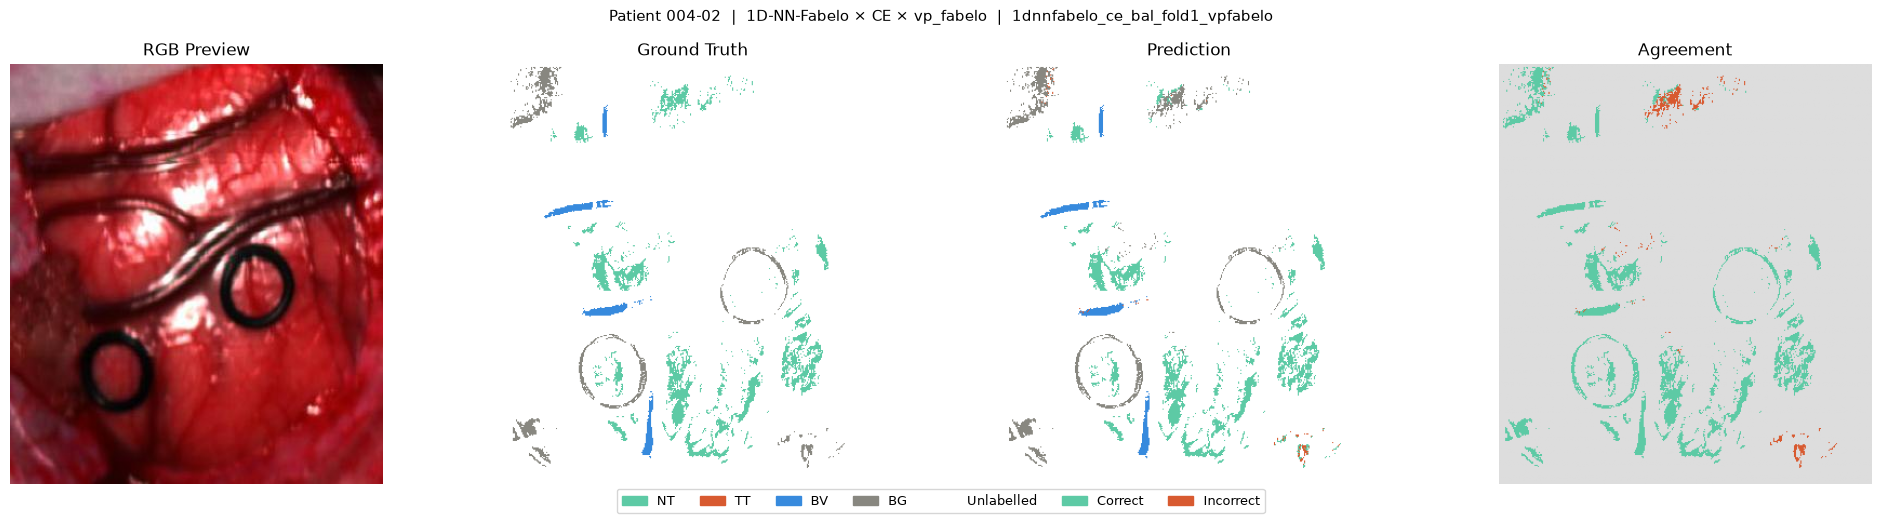

  Saved → ../results/1dnnfabelo_ce_bal_fold1_vpfabelo_004-02_predmap.png

  Pixel accuracy — 004-02
  Labelled            :    7,964
  Correct             :    7,311  (91.8%)
  Incorrect           :      653  (8.2%)

  Class     GT px   Correct     Acc
  ───────────────────────────────────
  NT        5,007     4,552   90.9%
  TT            0         0    0.0%  ←
  BV          965       952   98.7%
  BG        1,992     1,807   90.7%

  Inference timing — 004-02
  Total time            :     13.4 ms  (0.01 s)
  Labelled pixels       :    7,964
  Time per pixel        :   0.0017 ms
  Pixels per second     :  593,227

  ✅ Meets real-time constraint (<60s): 0.01s

── 012-01 ─────────────────────────────────────────────
  Found 012-01 in Campaign 1
  Image shape : (443, 497, 128)
  Running inference...


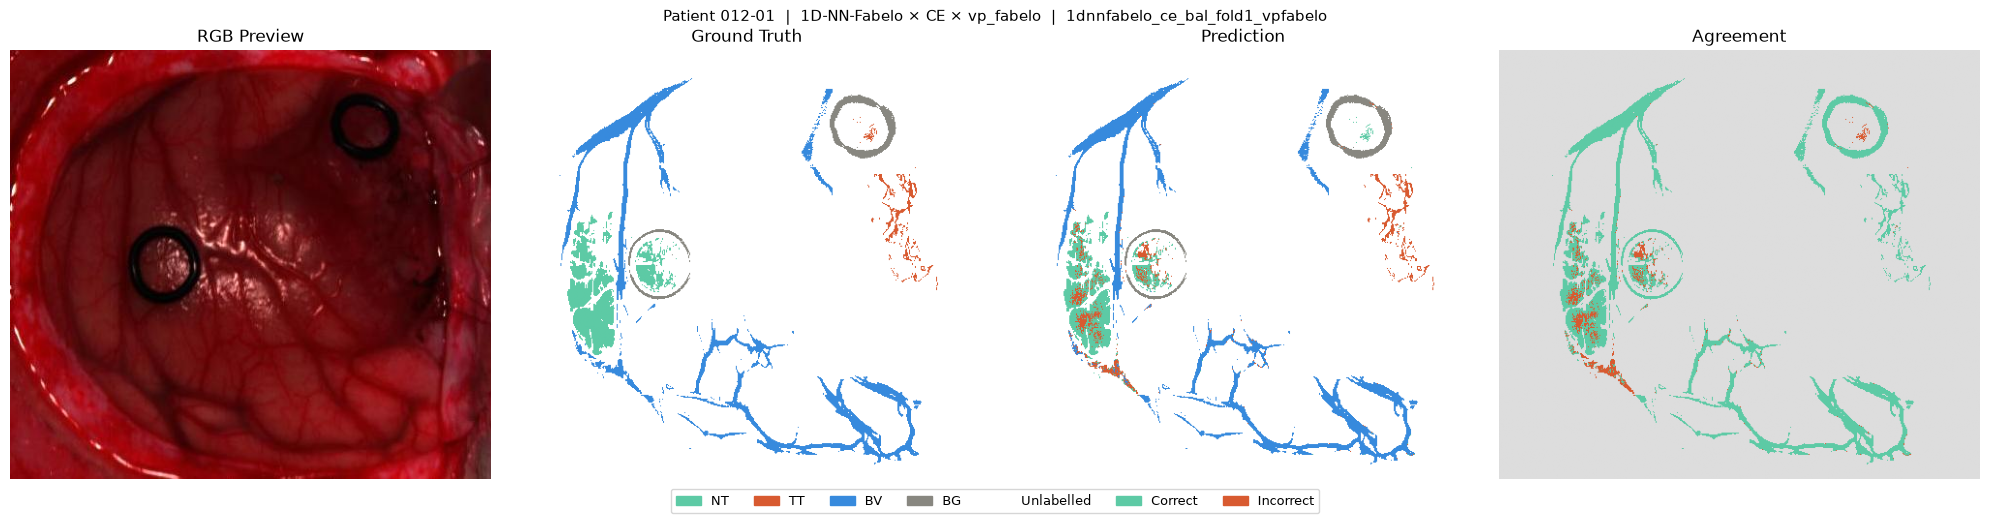

  Saved → ../results/1dnnfabelo_ce_bal_fold1_vpfabelo_012-01_predmap.png

  Pixel accuracy — 012-01
  Labelled            :   15,753
  Correct             :   14,258  (90.5%)
  Incorrect           :    1,495  (9.5%)

  Class     GT px   Correct     Acc
  ───────────────────────────────────
  NT        4,516     3,597   79.7%
  TT          855       776   90.8%  ←
  BV        8,697     8,216   94.5%
  BG        1,685     1,669   99.1%

  Inference timing — 012-01
  Total time            :     14.2 ms  (0.01 s)
  Labelled pixels       :   15,753
  Time per pixel        :   0.0009 ms
  Pixels per second     : 1,112,176

  ✅ Meets real-time constraint (<60s): 0.01s


In [60]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

print(f"\n{'═'*60}")
print(f"  Prediction maps — {MODEL} × {LOSS_FN} × {STRATEGY}")
print(f"  Run: {run_name}")
print(f"{'═'*60}\n")

for patient_id in VISUALISE_PATIENTS:
    print(f"\n── {patient_id} {'─'*45}")
    patient = load_patient_for_viz(patient_id)
    if patient is None:
        continue
    print(f"  Image shape : {patient['processed'].shape}")
    print(f"  Running inference...")
    pred_map, timing = predict_full_image(patient)
    plot_prediction_map(patient, pred_map, timing)